# CC3092 - Laboratorio 7 - Task 2

LSTM many-to-one implementado manualmente con tensores PyTorch (sin `nn.LSTM`), entrenado para horizontes $H=24$ y $H=48$ y comparado contra el baseline naive.

## Setup (reproduce el Task 1)

Este notebook es autocontenido: se repite el pipeline de `Lab7_Task1.ipynb` (normalizacion z-score de `OT`, split temporal 60/20/20 y ventanas con $L=96$, $H\in\{24,48\}$). La explicacion detallada de cada paso esta en el notebook del Task 1.

In [1]:
import json
import math
import urllib.request
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import torch
import torch.nn as nn
import torch.nn.functional as F

torch.manual_seed(42)
np.random.seed(42)

URL = ("https://raw.githubusercontent.com/zhouhaoyi/"
       "ETDataset/main/ETT-small/ETTh1.csv")
DATA_PATH = Path("ETTh1.csv")
RESULTS_DIR = Path("results")
RESULTS_DIR.mkdir(exist_ok=True)

if not DATA_PATH.exists():
    urllib.request.urlretrieve(URL, DATA_PATH)

In [2]:
data = np.genfromtxt(DATA_PATH, delimiter=",", skip_header=1)
OT = data[:, -1].astype(np.float32)       # Variable objetivo: Oil Temperature
ALL = data[:, 1:].astype(np.float32)      # Las 7 variables numericas

# z-score: x_norm = (x - mu) / sigma  (mu y sigma se guardan para desnormalizar)
mu = OT.mean()
sigma = OT.std()
OT_norm = (OT - mu) / sigma

# Split temporal contiguo: [train 60% | val 20% | test 20%], sin mezclar.
N_total = len(OT_norm)
n_train = int(0.60 * N_total)
n_val = int(0.20 * N_total)
OT_train = torch.from_numpy(OT_norm[:n_train].copy())
OT_val = torch.from_numpy(OT_norm[n_train:n_train + n_val].copy())
OT_test = torch.from_numpy(OT_norm[n_train + n_val:].copy())


def make_windows(series, L, H):
    # X^(t) = (x_{t-L+1}, ..., x_t),  y^(t) = x_{t+H}
    series = torch.as_tensor(series, dtype=torch.float32).flatten()
    n_examples = series.numel() - L - H + 1
    X = series.unfold(dimension=0, size=L, step=1)[:n_examples].clone()
    start_y = L + H - 1
    y = series[start_y:start_y + n_examples].clone()
    return X, y


L = 96
X_tr_24, y_tr_24 = make_windows(OT_train, L=L, H=24)
X_vl_24, y_vl_24 = make_windows(OT_val,   L=L, H=24)
X_ts_24, y_ts_24 = make_windows(OT_test,  L=L, H=24)
X_tr_48, y_tr_48 = make_windows(OT_train, L=L, H=48)
X_vl_48, y_vl_48 = make_windows(OT_val,   L=L, H=48)
X_ts_48, y_ts_48 = make_windows(OT_test,  L=L, H=48)

# Baseline naive: y_hat = x_t (ultimo valor observado de la ventana)
naive_mae = torch.abs(y_vl_24 - X_vl_24[:, -1]).mean().item()
naive_mae_48 = torch.abs(y_vl_48 - X_vl_48[:, -1]).mean().item()

print(f"mu={mu:.4f}, sigma={sigma:.4f}")
print(f"train H=24: {tuple(X_tr_24.shape)}, val H=24: {tuple(X_vl_24.shape)}")
print(f"Naive MAE val: H=24 -> {naive_mae:.4f}, H=48 -> {naive_mae_48:.4f}")

mu=13.3247, sigma=8.5667
train H=24: (10333, 96), val H=24: (3365, 96)
Naive MAE val: H=24 -> 0.1996, H=48 -> 0.2604


## Task 2.1 - `LSTMForecaster`

Ecuaciones de la celda LSTM en cada paso $t$:

$$\begin{aligned}
[\,i_t;\ f_t;\ g_t;\ o_t\,] &= x_t W_x^\top + h_{t-1} W_h^\top + b \\
i_t = \sigma(\cdot),\quad f_t &= \sigma(\cdot),\quad o_t = \sigma(\cdot),\quad g_t = \tanh(\cdot) \\
c_t &= f_t \odot c_{t-1} + i_t \odot g_t \\
h_t &= o_t \odot \tanh(c_t) \\
\hat y &= h_T W_{out}^\top + b_{out}
\end{aligned}$$

In [3]:
import torch.nn as nn
import torch.nn.functional as F

class LSTMForecaster(nn.Module):
    def __init__(self, d_in, d_h):
        super().__init__()
        self.d_h = d_h
        # SU CODIGO: declare los pesos de las 4 compuertas
        # Wx: (4*d_h, d_in), Wh: (4*d_h, d_h), b: (4*d_h,)
        # W_out: (1, d_h), b_out: (1,)
        # Use nn.Parameter para que sean aprendibles

        # SU CODIGO AQUI
        # Inicializacion uniforme en [-1/sqrt(d_h), 1/sqrt(d_h)] (igual que PyTorch)
        k = 1.0 / math.sqrt(d_h)
        # Pesos de las 4 compuertas apilados [i; f; g; o]
        self.Wx = nn.Parameter(torch.empty(4 * d_h, d_in).uniform_(-k, k))   # (4*d_h, d_in)
        self.Wh = nn.Parameter(torch.empty(4 * d_h, d_h).uniform_(-k, k))    # (4*d_h, d_h)
        self.b = nn.Parameter(torch.empty(4 * d_h).uniform_(-k, k))          # (4*d_h,)
        # Capa de salida: h_T -> escalar
        self.W_out = nn.Parameter(torch.empty(1, d_h).uniform_(-k, k))       # (1, d_h)
        self.b_out = nn.Parameter(torch.zeros(1))                            # (1,)
        # FIN SU CODIGO

    def forward(self, x):
        """
        Parametros
        ----------
        x : Tensor (B, L): batch de secuencias univariadas

        Retorna
        -------
        pred : Tensor (B,): prediccion escalar por secuencia

        Pasos:
        1. Reshape x a (B, L, 1) para procesarlo paso a paso
        2. Inicializar h y c en ceros: forma (B, d_h)
        3. Para cada paso t en range(L):
           a. Calcular gates = x[:,t,:] @ Wx.T + h @ Wh.T + b
           b. Separar en i, f, g, o de dimension d_h cada una
           c. Aplicar sigmoid a i, f, o y tanh a g
           d. Actualizar c = f*c + i*g
           e. Actualizar h = o*torch.tanh(c)
        4. Proyectar h_T con W_out: pred = h @ W_out.T + b_out
        5. Retornar pred.squeeze(-1)
        """
        # SU CODIGO AQUI
        # 1. x: (B, L) -> (B, L, 1) para procesar un escalar por paso
        B, L = x.shape
        x = x.unsqueeze(-1)
        # 2. Estados iniciales h_0 = c_0 = 0
        h = x.new_zeros(B, self.d_h)
        c = x.new_zeros(B, self.d_h)
        for t in range(L):
            # 3a. gates = x_t Wx^T + h_{t-1} Wh^T + b   -> (B, 4*d_h)
            gates = x[:, t, :] @ self.Wx.T + h @ self.Wh.T + self.b
            # 3b. Separar compuertas
            i, f, g, o = gates.chunk(4, dim=-1)
            # 3c. Activaciones
            i = torch.sigmoid(i)      # compuerta de entrada
            f = torch.sigmoid(f)      # compuerta de olvido
            g = torch.tanh(g)         # candidato a memoria
            o = torch.sigmoid(o)      # compuerta de salida
            # 3d. c_t = f_t * c_{t-1} + i_t * g_t
            c = f * c + i * g
            # 3e. h_t = o_t * tanh(c_t)
            h = o * torch.tanh(c)
        # 4. Many-to-one: solo se usa el ultimo estado oculto h_T
        pred = h @ self.W_out.T + self.b_out
        # 5.
        return pred.squeeze(-1)       # (B,)
        # FIN SU CODIGO

## Task 2.2 - Entrenamiento y evaluacion

Hiperparametros del enunciado: `d_h=32`, Adam, 20 epocas, `batch_size=64`. Funcion de perdida usada: **MSE** (la justificacion va en las preguntas de analisis).

### Prediccion residual respecto al ultimo valor

El nivel de `OT` cambia entre splits (media normalizada de train $\approx +0.46$, de validacion $\approx -0.74$). Un modelo que predice el nivel absoluto aprende el nivel de train y generaliza mal. Por eso, con `RESIDUAL = True`, el modelo recibe la ventana centrada en su ultimo valor y predice el cambio:

$$\tilde X^{(t)} = X^{(t)} - x_t,\qquad \tilde y^{(t)} = x_{t+H} - x_t,\qquad \hat y^{(t)} = x_t + f_\theta(\tilde X^{(t)})$$

La clase del modelo no cambia; solo cambian la entrada y el objetivo. Con $f_\theta \equiv 0$ se recupera exactamente el baseline naive, asi que el modelo aprende una correccion sobre el.

In [4]:
RESIDUAL = True   # ver celda anterior; False = predecir el nivel absoluto x_{t+H}


def prepare(X, y=None):
    # X~ = X - x_t,  y~ = y - x_t  (si RESIDUAL); x_t = ultimo valor de cada ventana
    last = X[:, -1] if RESIDUAL else torch.zeros(X.shape[0])
    X_in = X - last.unsqueeze(1)
    y_in = None if y is None else y - last
    return X_in, y_in, last


def train_model(model, X, y, epochs=20, batch_size=64, lr=1e-3, loss_fn=None):
    # Entrenamiento con mini-batches y Adam. Se barajan las ventanas de train
    # (cada ventana es un ejemplo independiente); el split sigue siendo temporal.
    loss_fn = loss_fn or nn.MSELoss()
    optimizer = torch.optim.Adam(model.parameters(), lr=lr)
    X, y, _ = prepare(X, y)
    history = []
    n = X.shape[0]
    for epoch in range(1, epochs + 1):
        model.train()
        perm = torch.randperm(n)
        total = 0.0
        for start in range(0, n, batch_size):
            idx = perm[start:start + batch_size]
            optimizer.zero_grad()
            loss = loss_fn(model(X[idx]), y[idx])
            loss.backward()                    # gradientes via autograd (BPTT en el LSTM)
            optimizer.step()
            total += loss.item() * idx.numel()
        history.append(total / n)
        print(f"  epoca {epoch:2d}/{epochs}  loss={history[-1]:.5f}")
    return history


@torch.no_grad()
def predict(model, X, batch_size=512):
    # y_hat = x_t + f(X~)  (si RESIDUAL; si no, last = 0)
    model.eval()
    X_in, _, last = prepare(X)
    out = torch.cat([model(X_in[i:i + batch_size]) for i in range(0, X.shape[0], batch_size)])
    return out + last


def compute_metrics(y, pred, naive_mae_ref):
    # MAE = mean|y - y_hat|,  RMSE = sqrt(mean (y - y_hat)^2),  ratio = MAE / MAE_naive
    mae = torch.abs(y - pred).mean().item()
    rmse = torch.sqrt(((y - pred) ** 2).mean()).item()
    return {
        "mae": mae,
        "rmse": rmse,
        "ratio": mae / naive_mae_ref,
        # En grados Celsius: el error escala por sigma al desnormalizar
        "mae_C": mae * float(sigma),
        "rmse_C": rmse * float(sigma),
    }


def print_metrics(name, m):
    print(f"{name}: MAE={m['mae']:.4f} ({m['mae_C']:.3f} C) | "
          f"RMSE={m['rmse']:.4f} ({m['rmse_C']:.3f} C) | ratio vs naive={m['ratio']:.3f}")

In [5]:
EPOCHS, BATCH_SIZE, LR = 20, 64, 1e-3

print("Entrenando LSTM H=24")
torch.manual_seed(42)
lstm_24 = LSTMForecaster(d_in=1, d_h=32)
loss_hist_24 = train_model(lstm_24, X_tr_24, y_tr_24, EPOCHS, BATCH_SIZE, LR)

Entrenando LSTM H=24


  epoca  1/20  loss=0.14804


  epoca  2/20  loss=0.14331


  epoca  3/20  loss=0.14111


  epoca  4/20  loss=0.14159


...

  epoca 16/20  loss=0.14071


  epoca 17/20  loss=0.14086


  epoca 18/20  loss=0.13903


  epoca 19/20  loss=0.13802


  epoca 20/20  loss=0.14098


In [6]:
print("Entrenando LSTM H=48")
torch.manual_seed(42)
lstm_48 = LSTMForecaster(d_in=1, d_h=32)
loss_hist_48 = train_model(lstm_48, X_tr_48, y_tr_48, EPOCHS, BATCH_SIZE, LR)

Entrenando LSTM H=48


  epoca  1/20  loss=0.23620


  epoca  2/20  loss=0.21777


  epoca  3/20  loss=0.21864


  epoca  4/20  loss=0.21956


...

  epoca 16/20  loss=0.22657


  epoca 17/20  loss=0.22621


  epoca 18/20  loss=0.22217


  epoca 19/20  loss=0.21874


  epoca 20/20  loss=0.21422


In [7]:
pred_vl_24 = predict(lstm_24, X_vl_24)
pred_vl_48 = predict(lstm_48, X_vl_48)

lstm_metrics = {
    "24": compute_metrics(y_vl_24, pred_vl_24, naive_mae),
    "48": compute_metrics(y_vl_48, pred_vl_48, naive_mae_48),
}
print_metrics("LSTM H=24", lstm_metrics["24"])
print_metrics("LSTM H=48", lstm_metrics["48"])

LSTM H=24: MAE=0.1959 (1.679 C) | RMSE=0.2602 (2.229 C) | ratio vs naive=0.982
LSTM H=48: MAE=0.2389 (2.047 C) | RMSE=0.3096 (2.653 C) | ratio vs naive=0.918


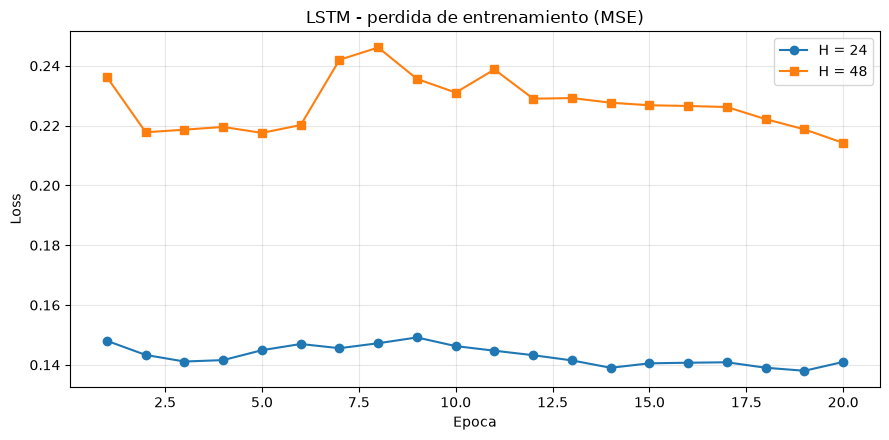

In [8]:
fig, ax = plt.subplots(figsize=(9, 4.5))
epochs_axis = np.arange(1, EPOCHS + 1)
ax.plot(epochs_axis, loss_hist_24, marker="o", label="H = 24")
ax.plot(epochs_axis, loss_hist_48, marker="s", label="H = 48")
ax.set(title="LSTM - perdida de entrenamiento (MSE)", xlabel="Epoca", ylabel="Loss")
ax.grid(alpha=0.3)
ax.legend()
plt.tight_layout()
plt.show()

In [9]:
# Se guardan resultados para el Task 4
with open(RESULTS_DIR / "lstm_metrics.json", "w") as fh:
    json.dump(lstm_metrics, fh, indent=2)
with open(RESULTS_DIR / "lstm_loss.json", "w") as fh:
    json.dump({"24": loss_hist_24, "48": loss_hist_48}, fh, indent=2)
print("Resultados guardados en", RESULTS_DIR.resolve())

Resultados guardados en C:\Users\richi\Documents\2026_S2_Local\Deep-Learning\app\results


## Verificacion oficial del Task 2

In [10]:
# Verificar shapes del forward
_model_test = LSTMForecaster(d_in=1, d_h=32)
_x_test = torch.randn(8, 96)
_pred_test = _model_test(_x_test)
assert _pred_test.shape == (8,), \
    f"Shape incorrecto: {_pred_test.shape} (esperado (8,))"

# Verificar que el modelo supera al naive en H=24
mae_lstm_24 = torch.abs(y_vl_24 - pred_vl_24).mean().item()
assert mae_lstm_24 < naive_mae * 1.1, \
    f"LSTM H=24 no supera al naive: {mae_lstm_24:.4f} vs {naive_mae:.4f}"

print(f"Task 2: CORRECTO")
print(f"  LSTM H=24: MAE={mae_lstm_24:.4f}, ratio={mae_lstm_24/naive_mae:.3f}")

Task 2: CORRECTO
  LSTM H=24: MAE=0.1959, ratio=0.982


## Preguntas de analisis

### Task 2.2a - Justificacion de la funcion de perdida

> "Use la funcion de perdida que considere apropiada para este problema y justifique su eleccion en las preguntas de analisis."

**Respuesta:** Se uso el error cuadratico medio, $\mathcal{L}_{MSE}=\frac{1}{N}\sum_i (y_i-\hat y_i)^2$, por cuatro razones:

1. **Es la perdida natural para regresion de un valor continuo.** Minimizar MSE equivale a maxima verosimilitud bajo ruido gaussiano, y su minimizador es la media condicional $\mathbb{E}[x_{t+H}\mid X^{(t)}]$, que es la prediccion puntual optima en sentido cuadratico.
2. **Penaliza mas los errores grandes.** El error entra al cuadrado, asi que un error de 5 °C pesa cuatro veces mas que uno de 2.5 °C. En este problema eso es deseable: subestimar un pico de temperatura del aceite es justamente el caso que puede terminar en falla termica.
3. **Tiene un gradiente suave y proporcional al error**, $\partial\mathcal{L}/\partial\hat y = 2(\hat y - y)$. Con MAE el gradiente es constante ($\pm 1$) y no esta definido en 0, lo que da una convergencia menos estable con Adam y batches de 64. Ademas, MSE es coherente con el RMSE que se reporta.
4. **Los datos estan normalizados** (escala ~1), asi que la perdida cuadratica no explota numericamente.

**Limitacion:** el objetivo residual $x_{t+H}-x_t$ tiene colas pesadas en train (curtosis 5.6 para $H=24$ y 4.9 para $H=48$, contra 3 de una gaussiana). MSE es sensible a esos cambios extremos, y una alternativa seria Huber. Se mantuvo MSE porque esos cambios extremos son los eventos de riesgo que interesa no subestimar. Aun asi, el MAE del LSTM en validacion quedo por debajo del naive: 0.1959 contra 0.1996 ($H=24$) y 0.2389 contra 0.2604 ($H=48$).

## Registro de uso limitado de IA generativa

### Prompt 1 — Estructura y código de los notebooks

**Prompt utilizado:** "¿Puedes hacer los notebooks con la estructura de código que se pide en ellos? Aún sin responder, pero con el código que se pide, para ya tener un orden de estos."

**Por qué funcionó:**

- **Limitó el alcance:** se pidió solo el código que exige el PDF, dejando las preguntas de análisis sin responder. La respuesta se enfocó en implementar lo solicitado sin mezclarlo con la interpretación de resultados.
- **Usó el PDF como referencia:** los esqueletos, docstrings y celdas de verificación se tomaron directamente del documento del laboratorio.
- **Pidió orden:** un notebook por task, cada uno autocontenido, lo que facilita revisar cada entrega por separado.
- **Se validó ejecutando:** el código se comprobó corriendo todas las celdas en orden y confirmando que las verificaciones oficiales del PDF imprimen 